# 05 Final Results and Visualization

Notebook ini digunakan untuk merangkum hasil akhir dari proses modeling pada Notebook 4.

Fokus notebook ini adalah:

1. Membaca hasil evaluasi model.
2. Membuat visualisasi perbandingan performa model.
3. Membaca dan menampilkan confusion matrix model terbaik.
4. Membuat visualisasi confusion matrix.
5. Menyusun ringkasan hasil akhir untuk kebutuhan laporan dan presentasi.

Notebook ini tidak melakukan training ulang model. Notebook ini hanya menggunakan output dari Notebook 4.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## Inisialisasi Path Project

In [2]:
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name.lower() == "notebooks":
    BASE_DIR = CURRENT_DIR.parent
else:
    BASE_DIR = CURRENT_DIR

RESULTS_DIR = BASE_DIR / "results"
MODELING_DIR = RESULTS_DIR / "modeling"
FINAL_DIR = RESULTS_DIR / "final"

FINAL_DIR.mkdir(parents=True, exist_ok=True)

model_evaluation_path = MODELING_DIR / "model_evaluation_results.csv"
confusion_matrix_path = MODELING_DIR / "confusion_matrix_best_model_named.csv"

print("Base directory       :", BASE_DIR)
print("Modeling result dir  :", MODELING_DIR)
print("Final result dir     :", FINAL_DIR)
print("Evaluation file      :", model_evaluation_path)
print("Confusion matrix file:", confusion_matrix_path)

Base directory       : e:\DOCUMENTS\PERKULIAHAN\SEMESTER 8\JOKI\TUGAS\Big Data\Tubes\code
Modeling result dir  : e:\DOCUMENTS\PERKULIAHAN\SEMESTER 8\JOKI\TUGAS\Big Data\Tubes\code\results\modeling
Final result dir     : e:\DOCUMENTS\PERKULIAHAN\SEMESTER 8\JOKI\TUGAS\Big Data\Tubes\code\results\final
Evaluation file      : e:\DOCUMENTS\PERKULIAHAN\SEMESTER 8\JOKI\TUGAS\Big Data\Tubes\code\results\modeling\model_evaluation_results.csv
Confusion matrix file: e:\DOCUMENTS\PERKULIAHAN\SEMESTER 8\JOKI\TUGAS\Big Data\Tubes\code\results\modeling\confusion_matrix_best_model_named.csv


## Membaca Hasil Evaluasi Model

In [3]:
evaluation_df = pd.read_csv(model_evaluation_path)

evaluation_df

,model,accuracy,precision,recall,f1_score
0,Decision Tree,0.892878,0.891373,0.892878,0.890051
1,Logistic Regression,0.753065,0.743065,0.753065,0.742018
2,Random Forest,0.702860,0.731553,0.702860,0.650359


## Menentukan Model Terbaik

Model terbaik dipilih berdasarkan nilai `f1_score` tertinggi. F1-score digunakan karena metrik ini mempertimbangkan keseimbangan antara precision dan recall.

In [4]:
evaluation_df = evaluation_df.sort_values("f1_score", ascending=False).reset_index(drop=True)

best_model_name = evaluation_df.loc[0, "model"]
best_accuracy = evaluation_df.loc[0, "accuracy"]
best_precision = evaluation_df.loc[0, "precision"]
best_recall = evaluation_df.loc[0, "recall"]
best_f1 = evaluation_df.loc[0, "f1_score"]

print("Model terbaik berdasarkan F1-score:", best_model_name)
print(f"Accuracy : {best_accuracy:.4f}")
print(f"Precision: {best_precision:.4f}")
print(f"Recall   : {best_recall:.4f}")
print(f"F1-score : {best_f1:.4f}")

Model terbaik berdasarkan F1-score: Decision Tree
Accuracy : 0.8929
Precision: 0.8914
Recall   : 0.8929
F1-score : 0.8901


## Visualisasi Perbandingan Performa Model

Visualisasi ini digunakan untuk membandingkan performa setiap model berdasarkan accuracy, precision, recall, dan F1-score.

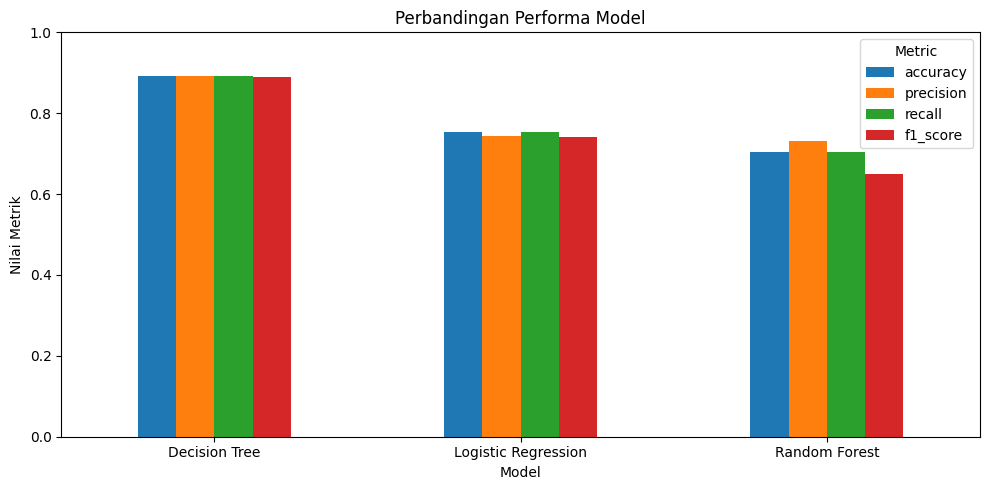

Grafik perbandingan performa model disimpan ke:
e:\DOCUMENTS\PERKULIAHAN\SEMESTER 8\JOKI\TUGAS\Big Data\Tubes\code\results\final\model_performance_comparison.png


In [5]:
metrics = ["accuracy", "precision", "recall", "f1_score"]

plot_df = evaluation_df.set_index("model")[metrics]

ax = plot_df.plot(kind="bar", figsize=(10, 5))

plt.title("Perbandingan Performa Model")
plt.xlabel("Model")
plt.ylabel("Nilai Metrik")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(title="Metric")
plt.tight_layout()

performance_plot_path = FINAL_DIR / "model_performance_comparison.png"
plt.savefig(performance_plot_path, dpi=300)
plt.show()

print("Grafik perbandingan performa model disimpan ke:")
print(performance_plot_path)

## Visualisasi F1-score Setiap Model

F1-score ditampilkan secara terpisah karena digunakan sebagai dasar utama pemilihan model terbaik.

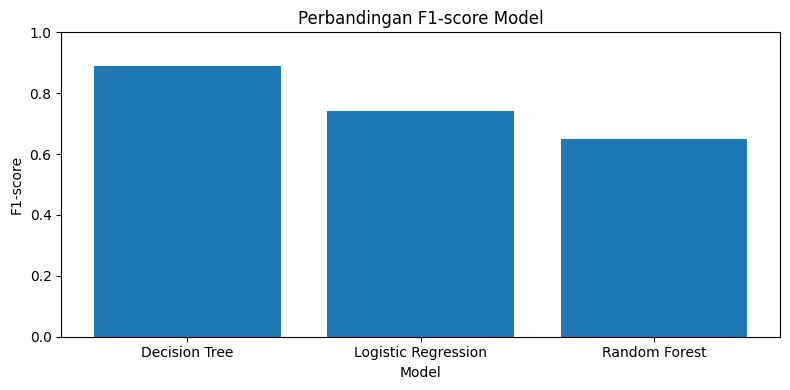

Grafik F1-score disimpan ke:
e:\DOCUMENTS\PERKULIAHAN\SEMESTER 8\JOKI\TUGAS\Big Data\Tubes\code\results\final\f1_score_comparison.png


In [6]:
plt.figure(figsize=(8, 4))

plt.bar(
    evaluation_df["model"],
    evaluation_df["f1_score"]
)

plt.title("Perbandingan F1-score Model")
plt.xlabel("Model")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()

f1_plot_path = FINAL_DIR / "f1_score_comparison.png"
plt.savefig(f1_plot_path, dpi=300)
plt.show()

print("Grafik F1-score disimpan ke:")
print(f1_plot_path)

## Membaca Confusion Matrix Model Terbaik

Confusion matrix digunakan untuk melihat pola prediksi benar dan salah pada setiap kelas demand.

In [7]:
confusion_matrix_df = pd.read_csv(confusion_matrix_path, index_col=0)

confusion_matrix_df

,High Demand,Low Demand,Medium Demand
Actual,,,
High Demand,295,79,53
Low Demand,16,1922,36
Medium Demand,50,133,842


## Visualisasi Confusion Matrix

Visualisasi ini membantu melihat kelas mana yang paling mudah atau paling sulit diprediksi oleh model terbaik.

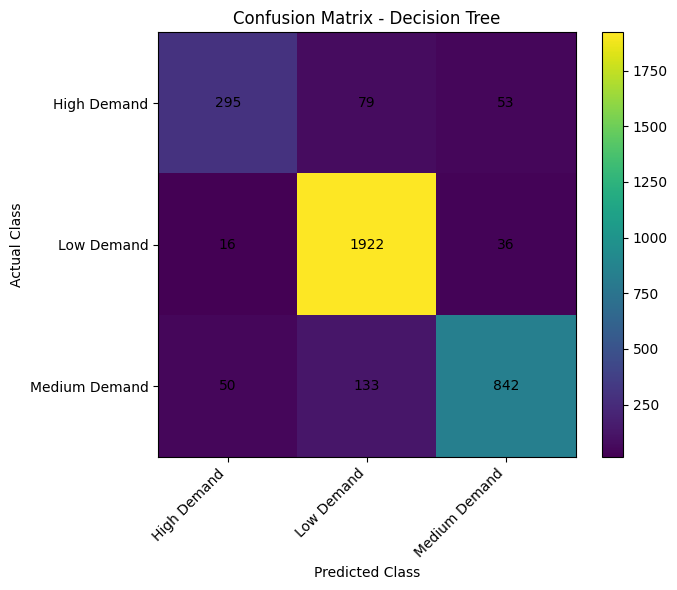

Grafik confusion matrix disimpan ke:
e:\DOCUMENTS\PERKULIAHAN\SEMESTER 8\JOKI\TUGAS\Big Data\Tubes\code\results\final\confusion_matrix_best_model.png


In [8]:
plt.figure(figsize=(7, 6))

plt.imshow(confusion_matrix_df.values, aspect="auto")
plt.colorbar()

plt.xticks(
    ticks=np.arange(len(confusion_matrix_df.columns)),
    labels=confusion_matrix_df.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    ticks=np.arange(len(confusion_matrix_df.index)),
    labels=confusion_matrix_df.index
)

for i in range(confusion_matrix_df.shape[0]):
    for j in range(confusion_matrix_df.shape[1]):
        plt.text(
            j,
            i,
            confusion_matrix_df.iloc[i, j],
            ha="center",
            va="center"
        )

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()

confusion_plot_path = FINAL_DIR / "confusion_matrix_best_model.png"
plt.savefig(confusion_plot_path, dpi=300)
plt.show()

print("Grafik confusion matrix disimpan ke:")
print(confusion_plot_path)

## Menghitung Akurasi per Kelas dari Confusion Matrix

Bagian ini digunakan untuk melihat performa model pada masing-masing kelas demand berdasarkan confusion matrix.

In [9]:
class_results = []

for class_name in confusion_matrix_df.index:
    actual_total = confusion_matrix_df.loc[class_name].sum()
    correct_prediction = confusion_matrix_df.loc[class_name, class_name] if class_name in confusion_matrix_df.columns else 0
    class_accuracy = correct_prediction / actual_total if actual_total > 0 else 0
    
    class_results.append({
        "class": class_name,
        "actual_total": actual_total,
        "correct_prediction": correct_prediction,
        "class_accuracy": class_accuracy
    })

class_results_df = pd.DataFrame(class_results)

class_results_df

,class,actual_total,correct_prediction,class_accuracy
0,High Demand,427,295,0.690867
1,Low Demand,1974,1922,0.973658
2,Medium Demand,1025,842,0.821463


In [10]:
class_results_path = FINAL_DIR / "class_prediction_summary.csv"
class_results_df.to_csv(class_results_path, index=False)

print("Ringkasan prediksi per kelas disimpan ke:")
print(class_results_path)

Ringkasan prediksi per kelas disimpan ke:
e:\DOCUMENTS\PERKULIAHAN\SEMESTER 8\JOKI\TUGAS\Big Data\Tubes\code\results\final\class_prediction_summary.csv


## Visualisasi Akurasi per Kelas

Visualisasi ini menunjukkan kelas demand mana yang paling baik dikenali oleh model terbaik.

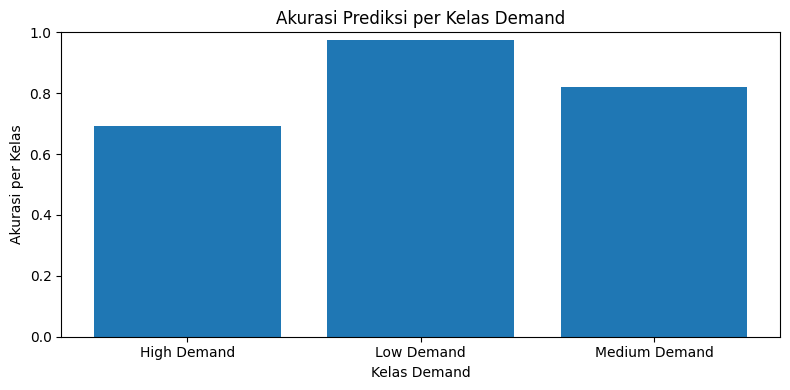

Grafik akurasi per kelas disimpan ke:
e:\DOCUMENTS\PERKULIAHAN\SEMESTER 8\JOKI\TUGAS\Big Data\Tubes\code\results\final\class_accuracy_comparison.png


In [11]:
plt.figure(figsize=(8, 4))

plt.bar(
    class_results_df["class"],
    class_results_df["class_accuracy"]
)

plt.title("Akurasi Prediksi per Kelas Demand")
plt.xlabel("Kelas Demand")
plt.ylabel("Akurasi per Kelas")
plt.ylim(0, 1)
plt.tight_layout()

class_accuracy_plot_path = FINAL_DIR / "class_accuracy_comparison.png"
plt.savefig(class_accuracy_plot_path, dpi=300)
plt.show()

print("Grafik akurasi per kelas disimpan ke:")
print(class_accuracy_plot_path)

## Membuat Ringkasan Hasil Akhir

Ringkasan ini dapat digunakan sebagai bahan awal untuk laporan dan presentasi.

In [12]:
summary_text = f"""
RINGKASAN HASIL AKHIR MODELING
========================================

Dataset yang digunakan merupakan dataset transaksi e-commerce Indonesia periode Januari 2024 sampai November 2025.
Target klasifikasi adalah tingkat permintaan produk yang dibagi menjadi tiga kelas, yaitu Low Demand, Medium Demand, dan High Demand.

Model yang dibandingkan:
{', '.join(evaluation_df['model'].tolist())}

Model terbaik berdasarkan F1-score:
{best_model_name}

Performa model terbaik:
Accuracy  : {best_accuracy:.4f}
Precision : {best_precision:.4f}
Recall    : {best_recall:.4f}
F1-score  : {best_f1:.4f}

Interpretasi singkat:
Model terbaik dipilih berdasarkan F1-score karena metrik ini mempertimbangkan keseimbangan antara precision dan recall.
Confusion matrix digunakan untuk melihat kemampuan model dalam membedakan kelas Low Demand, Medium Demand, dan High Demand.
"""

print(summary_text)


RINGKASAN HASIL AKHIR MODELING

Dataset yang digunakan merupakan dataset transaksi e-commerce Indonesia periode Januari 2024 sampai November 2025.
Target klasifikasi adalah tingkat permintaan produk yang dibagi menjadi tiga kelas, yaitu Low Demand, Medium Demand, dan High Demand.

Model yang dibandingkan:
Decision Tree, Logistic Regression, Random Forest

Model terbaik berdasarkan F1-score:
Decision Tree

Performa model terbaik:
Accuracy  : 0.8929
Precision : 0.8914
Recall    : 0.8929
F1-score  : 0.8901

Interpretasi singkat:
Model terbaik dipilih berdasarkan F1-score karena metrik ini mempertimbangkan keseimbangan antara precision dan recall.
Confusion matrix digunakan untuk melihat kemampuan model dalam membedakan kelas Low Demand, Medium Demand, dan High Demand.



In [13]:
summary_path = FINAL_DIR / "final_modeling_summary.txt"

with open(summary_path, "w", encoding="utf-8") as file:
    file.write(summary_text)

print("Ringkasan akhir disimpan ke:")
print(summary_path)

Ringkasan akhir disimpan ke:
e:\DOCUMENTS\PERKULIAHAN\SEMESTER 8\JOKI\TUGAS\Big Data\Tubes\code\results\final\final_modeling_summary.txt


## Daftar File Output Final

Bagian ini menampilkan file hasil akhir yang dapat digunakan untuk laporan.

In [14]:
output_files = sorted(FINAL_DIR.glob("*"))

print("Daftar output final:")
for file in output_files:
    print("-", file.name)

Daftar output final:
- class_accuracy_comparison.png
- class_prediction_summary.csv
- confusion_matrix_best_model.png
- f1_score_comparison.png
- final_modeling_summary.txt
- model_performance_comparison.png
